In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils.simulacoes import simular_PID, simular_step_test

from utils.plots import plot_results

In [2]:
tf = 100.0
dt = 0.1

X0 = 0.3066
S0 = 0.2333

states = np.array([0.3066, 0.2333])

Xsp = 0.3066

D0 = 0.35


In [3]:
def ajuste(individuo: list = None, tam: int = 6):
    completar = tam - len(individuo)
    while completar > 0:
        individuo.append('0')
        completar-=1
    return individuo

In [49]:
def sobrevivenciaMaisApto(tamanho_povo, N, erro_individuo_lim, gen, tf, dt):
    df = None
    historico_erro = []
    while N > 0:
        custo_erro = np.inf
        sobreviventes = []
        erro_sobreviventes = []

        for i in gen:
            # só se presta como gente
            if i[1] != 0:
                t1, X1, S1, D1, IAE, ISE, erro = simular_PID(Kc=i[0], Ti=i[1], Xsp=Xsp, D0=D0, states=states, tempo_final=tf, dt=dt, show=False)
                erro_individuo = erro[-1] 

                if erro_individuo <= erro_individuo_lim: 
                    sobreviventes.append(i)
                    erro_sobreviventes.append(erro_individuo)

                # menor erro dentro dessa geracao
                if custo_erro > erro_individuo:
                    custo_erro = erro_individuo
            
        historico_erro.append(custo_erro)
        df = pd.DataFrame({
                "sobreviventes": sobreviventes,
                "erro": erro_sobreviventes
            })
        # o menor custo de quem não morreu foi top, para aqui
        if abs(custo_erro) < 1e-5:
            break
        
        sobreviventes = np.array(sobreviventes)
        gen = np.zeros(shape=(tamanho_povo,2))
        for i in range(len(gen)):
            filho = np.zeros(2)

            # sodomia i
            idx_pai, idx_mae = np.random.choice(len(sobreviventes),size=2,replace=False)
            # print(f"idx_pai:{idx_pai}, idx_mae:{idx_mae}")

            # só no kzinho
            pai = sobreviventes[idx_pai, 0]
            mae = sobreviventes[idx_mae, 0]
            
            arr_p = np.array(ajuste(list(str(pai))))
            arr_m = np.array(ajuste(list(str(mae))))

            mask = np.array([
                    0,
                    np.random.randint(0, 2),
                    0,
                    np.random.randint(0, 2),
                    np.random.randint(0, 2),
                    np.random.randint(0, 2)
                ])
            
            filho[0] = float(''.join(np.where(mask, arr_m, arr_p)))

            # só no T
            pai = sobreviventes[idx_pai, 1]
            mae = sobreviventes[idx_mae, 1]
            
            arr_p = np.array(ajuste(list(str(pai)), 5))
            arr_m = np.array(ajuste(list(str(mae)), 5))

            mask = np.array([
                    np.random.randint(0, 2),
                    0,
                    np.random.randint(0, 2),
                    np.random.randint(0, 2),
                    np.random.randint(0, 2)
                ])
            
            filho[1] = float(''.join(np.where(mask, arr_m, arr_p)))

            # filho i
            # print(filho)
            gen[i] = filho

        N-=1
    return df, N, historico_erro
        

In [51]:
tamanho_povo = 100
N = 10
erro_individuo_lim = 1e-2

# g init
gen = np.column_stack([
    -np.round(np.random.uniform(0, 5, tamanho_povo), 3),  # sempre negativo
    np.round(np.random.uniform(0, 10, tamanho_povo), 3),
    # np.round(np.random.uniform(0, 10, tamanho_povo), 3)
])

for tuning_paramater_indice in range(len(gen)):
    while gen[tuning_paramater_indice, 1] == 0:
       gen[tuning_paramater_indice, 1] = np.round(np.random.uniform(0, 10), 3)
       print(gen[tuning_paramater_indice])

povo, N, historico_erro = sobrevivenciaMaisApto(tamanho_povo=tamanho_povo, N=N, erro_individuo_lim=erro_individuo_lim, gen=gen, dt=0.1, tf = 50)

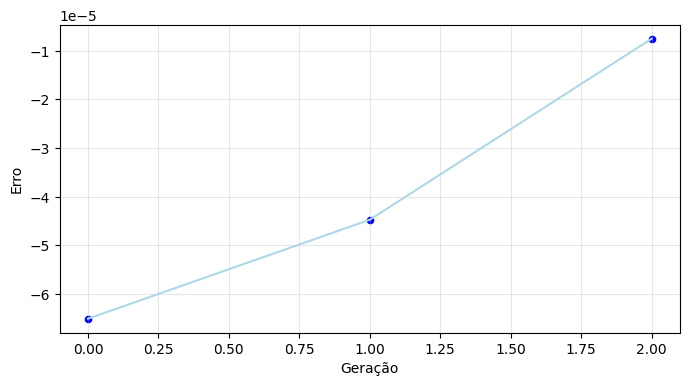

In [52]:
import matplotlib.pyplot as plt
import numpy as np

tempo = np.arange(len(historico_erro))

plt.figure(figsize=(8,4))

plt.plot(
    tempo,
    historico_erro,
    color='lightblue',
    linewidth=1.5
)

plt.scatter(
    tempo,
    historico_erro,
    color='blue',
    s=20
)

plt.xlabel("Geração")
plt.ylabel("Erro")
plt.grid(True, alpha=0.3)

plt.show()

In [58]:
povo = povo.sort_values(
    by="erro",
    key=lambda x: np.abs(x)
).reset_index(drop=True)

In [64]:
povo["sobreviventes"][0][0]

np.float64(-3.445)

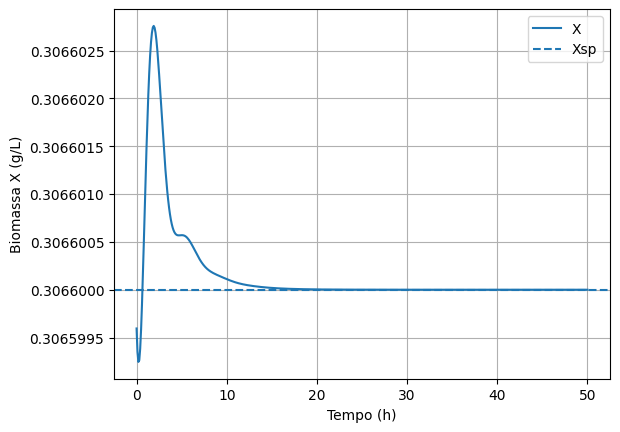

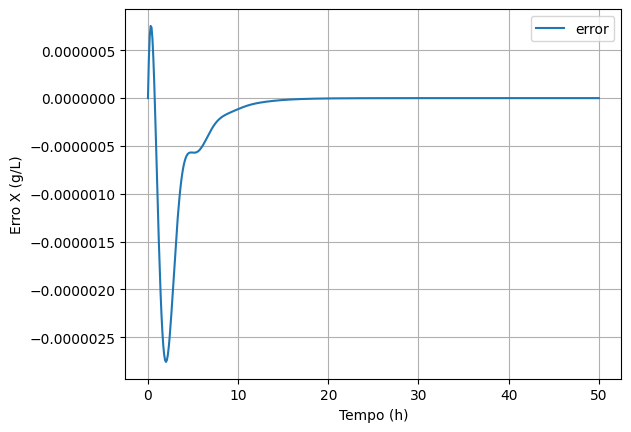

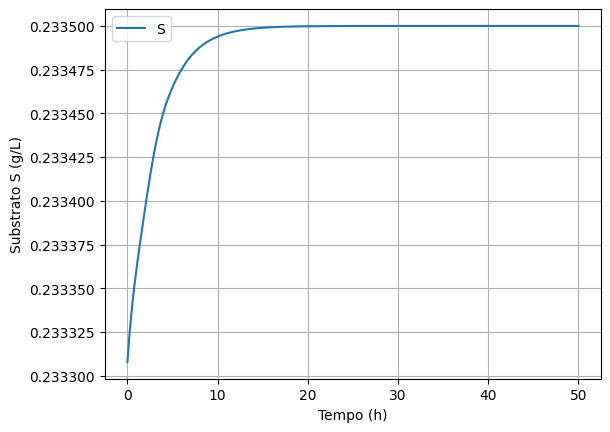

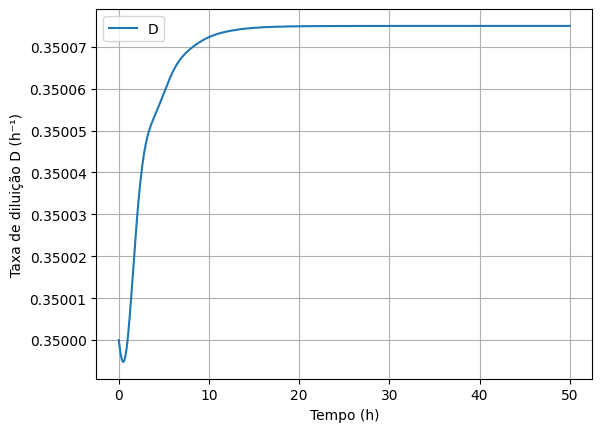

8.429727654449272e-06 1.2786834014506812e-11 -9.248157795127554e-14


In [66]:
ttop, Xtop, Stop, Dtop, IAE_top, ISE_top, erro = simular_PID(Kc=povo["sobreviventes"][0][0], Ti=povo["sobreviventes"][0][1], Xsp=Xsp, D0=D0, states=states, tempo_final=50, dt=0.1, show=True)
print(IAE_top, ISE_top, erro[-1])